## Práctico 1: Explorando técnicas para clasificación de vinos.

En este práctico se resolverá un problema de clasificación multiclase de distintas formas para fomentar una discusión acerca de qué técnica conviene más dependiendo del caso, además de definir métricas apropiadas para evaluar los modelos. 



### Librerías usadas:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn import datasets
from transformers import pipeline
import pandas as pd


c:\Users\AdminPC\AppData\Local\pypoetry\Cache\virtualenvs\clase-1-fiWa6Bvz-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


En caso de estar usando pip, puede instalarlos con el comando:
```
pip install -r requirements.txt
```
Si usa poetry, el comando es:
```
poetry install
```

In [2]:
#chequear si está cuda disponible para usar la GPU, sino usar CPU
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Dataset
Este dataset incluye información sobre tres clases de vinos producidos en Italia y 13 características (features)predictivas. En base a las características se debe predecir la clase de vino (simplemente llamada class_0, class_1 o class_2)

In [3]:
wines = datasets.load_wine()

features = wines.data
labels = wines.target

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.5, random_state=42)

In [4]:
df = pd.DataFrame(features, columns=wines.feature_names)
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Modelos tradicionales de ML

¿Cómo podemos resolver el problema de **clasificación**?

**Algoritmos**:
   - **Random Forest**.
   - **XGBoost**.
   - **Naive Bayes**.
   - **LightGBM** (Gradient boosting).
   - **Voting Classifier**: Combina múltiples modelos y se predice por votación.




In [5]:
# Constantes globalres utiles para el desarrollo
RANDOM_SEED = 42

# Ejercicio 1:

Entrenar un modelo a elección para resolver el problema de clasificación multiclase.


Recordatorio de algunas funciones básicas que pueden ser útiles:

- model.fit(X_train, y_train)
- model.predict(X_test)

Para evaluación:
- accuracy_score(y_test, predictions)
- f1_score(y_test, predictions, average='weighted')

Se pueden importar modelos (por ejemplo de sklearn).

In [6]:
# Contrucción y entrenamiento del un modelo Random Forest
random_seed = 42
rf_model = RandomForestClassifier(random_state=RANDOM_SEED)
rf_model.fit(X_train, y_train)

# Predicciónes en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluación del modelo Random Forest (accuracy y F1 Score)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Random Forest - Accuracy: {accuracy_rf:.4f}, F1 Score: {f1_rf:.4f}")

# Se muestra la complejidad del modelo Random Forest

Random Forest - Accuracy: 0.9775, F1 Score: 0.9775


## Exploración de datos

En la siguiente celda se estudia la correlación entre las features y el target.

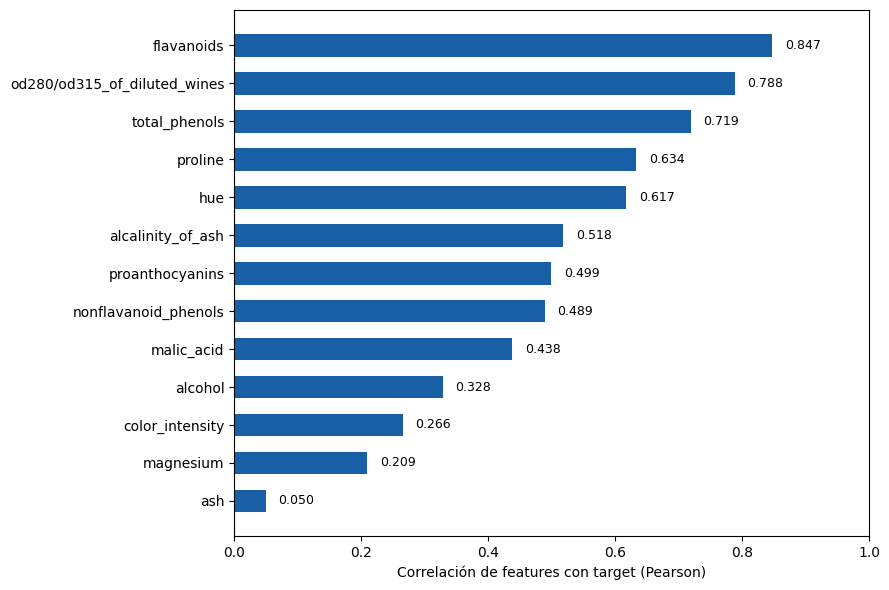

In [7]:
X, y = wines.data, wines.target


corrs = np.array([np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])])
corrs = np.abs(corrs)

order = np.argsort(np.abs(corrs))[::-1]
sorted_corrs  = corrs[order]
sorted_labels = np.array(wines.feature_names)[order]

colors = ['#185FA5' if c >= 0 else '#A32D2D' for c in sorted_corrs]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(sorted_labels, sorted_corrs, color=colors, height=0.6)

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel("Correlación de features con target (Pearson)")
ax.set_xlim(0, 1)
ax.invert_yaxis()

for bar, v in zip(bars, sorted_corrs):
    ax.text(v + (0.02), bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
import plotly.express as px
import pandas as pd
from sklearn import datasets

wines = datasets.load_wine()
X, y = wines.data, wines.target

df = pd.DataFrame({
    "Flavanoids":            X[:, 6],
    "OD280/OD315":           X[:, 11],
    "Total phenols":         X[:, 5],
    "Class": [wines.target_names[c] for c in y]
})

fig = px.scatter_3d(
    df,
    x="Flavanoids",
    y="OD280/OD315",
    z="Total phenols",
    color="Class",
    color_discrete_map={
        "class_0": "#185FA5",
        "class_1": "#854F0B",
        "class_2": "#0F6E56",
    },
    symbol="Class",
    opacity=0.85,
    title="Top 3 features — interactive 3D scatter by wine class",
)

fig.update_traces(marker=dict(size=5, line=dict(width=0.3, color="white")))
fig.update_layout(
    legend=dict(title="Wine class"),
    margin=dict(l=0, r=0, t=40, b=0),
    scene=dict(
        xaxis_title="Flavanoids",
        yaxis_title="OD280/OD315",
        zaxis_title="Total phenols",
    )
)

fig.write_html("wine_3d.html", auto_open=True)

<img src="imgs/scatter_plot_features.png" width="80%"/>

## ¿Se puede usar otro enfoque para resolver el problema? 

Observando la gráfica anterior, parece viable hacer un modelo predictor que use los clusters (o cúmulos) formados por las features para poder clasificar.

In [9]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.optimize import linear_sum_assignment
import numpy as np
from sklearn.decomposition import PCA

class KMeansClassifierAdapter(BaseEstimator, ClassifierMixin):
    def __init__(self, n_clusters=3, **kwargs):
        self.n_clusters = n_clusters
        self.kmeans = KMeans(n_clusters=n_clusters, **kwargs)
        self.mapping_ = {}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n = len(self.classes_)
        cluster_labels = self.kmeans.fit_predict(X)


        cost = np.zeros((n, n))
        for i in range(n): #Los clusters tienen una ID (0, 1 o 2), aquí alineamos esas ID con las tres clases que tiene el dataset
            for j in range(n):
                cost[i, j] = np.sum((y == self.classes_[i]) & (cluster_labels == j))
        _, col_ind = linear_sum_assignment(-cost)
        self.mapping_ = {col_ind[i]: self.classes_[i] for i in range(n)}



        #Tras identificar los clusters de 11 dimensiones, los graficamos. PCA nos permite reducir la dimensionalidad
        pca = PCA(n_components=2)
        X2  = pca.fit_transform(X)
        centroids_2d = pca.transform(self.kmeans.cluster_centers_)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for j in range(n):
            mask = cluster_labels == j
            axes[0].scatter(X2[mask, 0], X2[mask, 1], label=f"Cluster {j}", s=40, alpha=0.7)
        axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                        c="black", marker="X", s=180, zorder=5, label="Centroids")
        axes[0].set_title("KMeans — raw cluster IDs")
        axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
        axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
        axes[0].legend()
        aligned_labels = np.array([self.mapping_[c] for c in cluster_labels])
        for cls in self.classes_:
            mask = aligned_labels == cls
            axes[1].scatter(X2[mask, 0], X2[mask, 1], label=f"Class {cls}", s=40, alpha=0.7)
        axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                        c="black", marker="X", s=180, zorder=5, label="Centroids")
        axes[1].set_title("KMeans — aligned to true class labels")
        axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
        axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
        axes[1].legend()

        plt.suptitle("KMeans Clustering (PCA projection)", fontweight="bold")
        plt.tight_layout()
        plt.show()
        
        return self

    def predict(self, X):
        cluster_labels = self.kmeans.predict(X)
        return np.array([self.mapping_[c] for c in cluster_labels])

    def predict_proba(self, X):
        distances = self.kmeans.transform(X)       
        ordered = np.zeros_like(distances)
        for cluster_idx, class_idx in self.mapping_.items():
            ordered[:, class_idx] = distances[:, cluster_idx]
        # Obtengo la probabilidad como la distancia al centro del cluster (más cerca = mayor prob)
        inv = 1 / (ordered + 1e-9)
        return inv / inv.sum(axis=1, keepdims=True)

## Ejercicio 2: KMeans
Dado el modelo anterior ya implementado, entrenarlo y obtener métricas de performance.

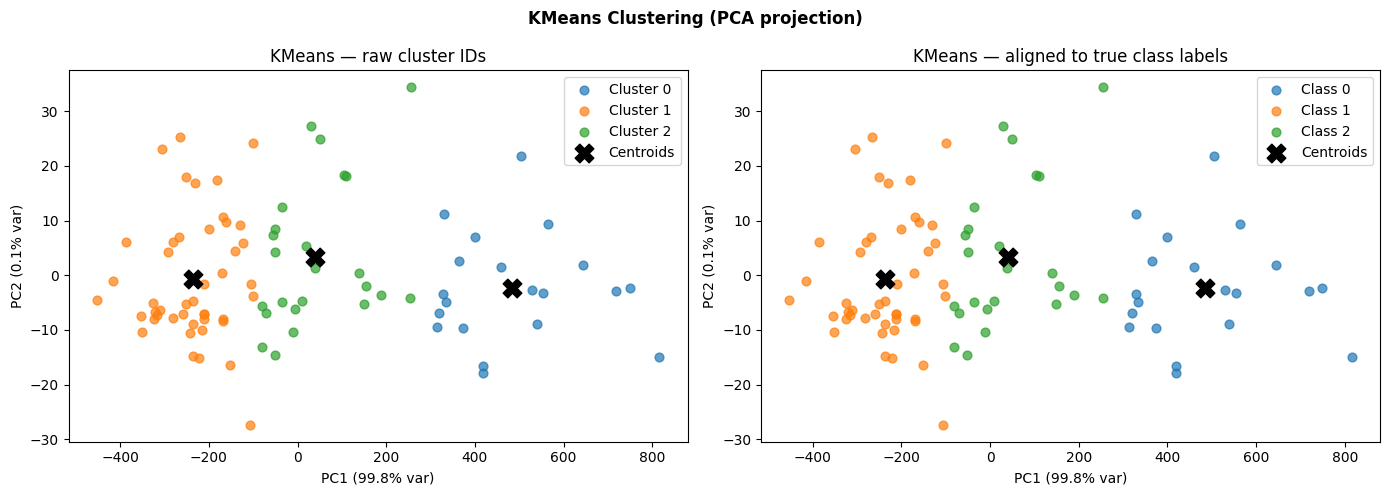

KMeans Classifier - Accuracy: 0.6067, F1 Score: 0.6296


In [10]:
# Contrcción y entrenamiento de un modelo KMeans para clasificación
kmeans_clf = KMeansClassifierAdapter(n_clusters=3, random_state=RANDOM_SEED)
kmeans_clf.fit(X_train, y_train)

# Predicciónes en el conjunto de prueba
y_pred_kmeans = kmeans_clf.predict(X_test)

# Evaluación del modelo KMeans (accuracy y F1 Score)
accuracy_kmeans = accuracy_score(y_test, y_pred_kmeans)
f1_kmeans = f1_score(y_test, y_pred_kmeans, average='weighted')
print(f"KMeans Classifier - Accuracy: {accuracy_kmeans:.4f}, F1 Score: {f1_kmeans:.4f}")


## Ejercicio 3: Regresión logística
Implementar una regresión logística que permita predecir la variable target. Entrenar el modelo y obtener métricas de performance.

In [11]:
# Creación y entranamiento de una regresión logística para clasificación
logreg_model = LogisticRegression(max_iter=4000, random_state=RANDOM_SEED)
logreg_model.fit(X_train, y_train)

# Predicciónes en el conjunto de prueba
y_pred_logreg = logreg_model.predict(X_test)

# Evaluación del modelo de regresión logística (accuracy y F1 Score)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')
print(f"Logistic Regression - Accuracy: {accuracy_logreg:.4f}, F1 Score: {f1_logreg:.4f}")

Logistic Regression - Accuracy: 0.9326, F1 Score: 0.9326


c:\Users\AdminPC\AppData\Local\pypoetry\Cache\virtualenvs\clase-1-fiWa6Bvz-py3.11\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Extra: Enfoque de Deep Learning
Podríamos entrenar una red neuronal para resolver el problema, por ejemplo, con un **multi-perceptrón**.

¿Existe una solución que no requiera entrenar? Un **modelo de lenguaje**.




Un modelo de lenguaje no está diseñado particularmente para clasificación, solo devuelve texto en base a una entrada, pero se ha popularizado en la industria el uso de modelos de lenguaje para clasificar imágenes y documentos dada su versatilidad, solo se debe cambiar la prompt para cambiar la tarea (son multi-propósito).

Ejemplo utilizando mistralai/Mistral-7B-Instruct-v0.2 

<img src="imgs/llm_prompt.png" width="80%"/>
<img src="imgs/llm_answer.png" width="50%"/>

<img src="imgs/results_llm.png" width="50%"/>

El código para implementar el modelo es el siguiente. No es parte del práctico replicar los resultados anteriores, esta sección es meramente discursiva.


In [12]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin


class LocalLLMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, X_train_examples, Y_train_examples, model_name="mistralai/Mistral-7B-Instruct-v0.2", n_examples_per_class=3):
        self.model_name = model_name
        self.n_examples_per_class = n_examples_per_class

        self.classes_ = np.unique(Y_train_examples)
        self.feature_names_ = wines.feature_names

        # Almacenamos ejemplos para agregar a la prompt
        self.examples_ = {}
        for cls in self.classes_:
            cls_indices = np.where(Y_train_examples == cls)[0]
            chosen = cls_indices[:self.n_examples_per_class]
            self.examples_[cls] = X_train_examples[chosen]

        self.pipe_ = pipeline( #Es necesario instalar e importar transformers si desean ejecutar este códiogo
            "text-generation",
            model=self.model_name,
            device=0 if torch.cuda.is_available() else -1
        )

    def fit(self, X, y):
        return self

    def _build_prompt(self, sample):
        """Few-shot prompt, contiene ejemplos de cada clase"""
        lines = ["Based on these examples, predict the class (0, 1 or 2) of the last sample.\n"]
        lines.append("Examples:")

        for cls in self.classes_:
            ex = np.atleast_1d(self.examples_[cls][0])  
            formatted = ", ".join(f"{n}={v:.2f}" for n, v in zip(self.feature_names_, ex))
            lines.append(f"  Sample: [{formatted}] → Class {cls}")
        formatted_x = ", ".join(f"{n}={v:.2f}" for n, v in zip(self.feature_names_, sample))
        lines.append(f"  Last sample: [{formatted_x}] → Class ")

        return "\n".join(lines)

    def _parse_response(self, response_text):
        """Extract the first valid class digit from the LLM output."""
        for char in response_text:
            if char in [str(c) for c in self.classes_]:
                return int(char)
        return int(self.classes_[0])              

    def predict(self, X):
        predictions = []
        for sample in X:
            prompt = self._build_prompt(sample)
            print("Prompt: \n", prompt, "\n")
            output = self.pipe_(
                prompt,
                max_new_tokens=15,               
                do_sample=False,                
                temperature=None,
                top_p=None,
            )
  
            generated = output[0]["generated_text"][len(prompt):]
            print("Answer", generated, "\n")
            pred = self._parse_response(generated)
            predictions.append(pred)

        return np.array(predictions)

    def predict_proba(self, X):
        preds = self.predict(X)
        proba = np.zeros((len(preds), len(self.classes_)))
        for i, p in enumerate(preds):
            proba[i, p] = 1.0
        return proba

In [13]:
'''
Aclaración: Si bien no se pide en el encunaciado del práctico se incluye la ejecución del modelo LocalLLMClassifier 
por que me resultó interesante el ejemplo.
'''

# Chequear si está cuda disponible para usar la GPU, sino usar CPU
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Creación y entrenamiento de un modelo LocalLLMClassifier 
llm_clf = LocalLLMClassifier(X_train, y_train, n_examples_per_class=3)

# Predicciónes en el conjunto de prueba
y_pred_llm = llm_clf.predict(X_test)

# Evaluación del modelo LocalLLMClassifier (accuracy y F1 Score)
accuracy_llm = accuracy_score(y_test, y_pred_llm)
f1_llm = f1_score(y_test, y_pred_llm, average='weighted')
print(f"LocalLLMClassifier - Accuracy: {accuracy_llm:.4f}, F1 Score: {f1_llm:.4f}")

Using device: cuda


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 2382.89it/s]
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Prompt: 
 Based on these examples, predict the class (0, 1 or 2) of the last sample.

Examples:
  Sample: [alcohol=14.22, malic_acid=3.99, ash=2.51, alcalinity_of_ash=13.20, magnesium=128.00, total_phenols=3.00, flavanoids=3.04, nonflavanoid_phenols=0.20, proanthocyanins=2.08, color_intensity=5.10, hue=0.89, od280/od315_of_diluted_wines=3.53, proline=760.00] → Class 0
  Sample: [alcohol=12.70, malic_acid=3.87, ash=2.40, alcalinity_of_ash=23.00, magnesium=101.00, total_phenols=2.83, flavanoids=2.55, nonflavanoid_phenols=0.43, proanthocyanins=1.95, color_intensity=2.57, hue=1.19, od280/od315_of_diluted_wines=3.13, proline=463.00] → Class 1
  Sample: [alcohol=13.71, malic_acid=5.65, ash=2.45, alcalinity_of_ash=20.50, magnesium=95.00, total_phenols=1.68, flavanoids=0.61, nonflavanoid_phenols=0.52, proanthocyanins=1.06, color_intensity=7.70, hue=0.64, od280/od315_of_diluted_wines=1.74, proline=740.00] → Class 2
  Last sample: [alcohol=13.64, malic_acid=3.10, ash=2.56, alcalinity_of_ash=15.2

Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Answer 0

The last sample has a low value of malic acid and 

Prompt: 
 Based on these examples, predict the class (0, 1 or 2) of the last sample.

Examples:
  Sample: [alcohol=14.22, malic_acid=3.99, ash=2.51, alcalinity_of_ash=13.20, magnesium=128.00, total_phenols=3.00, flavanoids=3.04, nonflavanoid_phenols=0.20, proanthocyanins=2.08, color_intensity=5.10, hue=0.89, od280/od315_of_diluted_wines=3.53, proline=760.00] → Class 0
  Sample: [alcohol=12.70, malic_acid=3.87, ash=2.40, alcalinity_of_ash=23.00, magnesium=101.00, total_phenols=2.83, flavanoids=2.55, nonflavanoid_phenols=0.43, proanthocyanins=1.95, color_intensity=2.57, hue=1.19, od280/od315_of_diluted_wines=3.13, proline=463.00] → Class 1
  Sample: [alcohol=13.71, malic_acid=5.65, ash=2.45, alcalinity_of_ash=20.50, magnesium=95.00, total_phenols=1.68, flavanoids=0.61, nonflavanoid_phenols=0.52, proanthocyanins=1.06, color_intensity=7.70, hue=0.64, od280/od315_of_diluted_wines=1.74, proline=740.00] → Class 2
  Last sample: [al

...

Answer 1

The last sample has a higher value of total phenols and 

Prompt: 
 Based on these examples, predict the class (0, 1 or 2) of the last sample.

Examples:
  Sample: [alcohol=14.22, malic_acid=3.99, ash=2.51, alcalinity_of_ash=13.20, magnesium=128.00, total_phenols=3.00, flavanoids=3.04, nonflavanoid_phenols=0.20, proanthocyanins=2.08, color_intensity=5.10, hue=0.89, od280/od315_of_diluted_wines=3.53, proline=760.00] → Class 0
  Sample: [alcohol=12.70, malic_acid=3.87, ash=2.40, alcalinity_of_ash=23.00, magnesium=101.00, total_phenols=2.83, flavanoids=2.55, nonflavanoid_phenols=0.43, proanthocyanins=1.95, color_intensity=2.57, hue=1.19, od280/od315_of_diluted_wines=3.13, proline=463.00] → Class 1
  Sample: [alcohol=13.71, malic_acid=5.65, ash=2.45, alcalinity_of_ash=20.50, magnesium=95.00, total_phenols=1.68, flavanoids=0.61, nonflavanoid_phenols=0.52, proanthocyanins=1.06, color_intensity=7.70, hue=0.64, od280/od315_of_diluted_wines=1.74, proline=740.00] → Class 2
  Last sampl

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Answer 1

The last sample has a higher value of total phenols and 

Prompt: 
 Based on these examples, predict the class (0, 1 or 2) of the last sample.

Examples:
  Sample: [alcohol=14.22, malic_acid=3.99, ash=2.51, alcalinity_of_ash=13.20, magnesium=128.00, total_phenols=3.00, flavanoids=3.04, nonflavanoid_phenols=0.20, proanthocyanins=2.08, color_intensity=5.10, hue=0.89, od280/od315_of_diluted_wines=3.53, proline=760.00] → Class 0
  Sample: [alcohol=12.70, malic_acid=3.87, ash=2.40, alcalinity_of_ash=23.00, magnesium=101.00, total_phenols=2.83, flavanoids=2.55, nonflavanoid_phenols=0.43, proanthocyanins=1.95, color_intensity=2.57, hue=1.19, od280/od315_of_diluted_wines=3.13, proline=463.00] → Class 1
  Sample: [alcohol=13.71, malic_acid=5.65, ash=2.45, alcalinity_of_ash=20.50, magnesium=95.00, total_phenols=1.68, flavanoids=0.61, nonflavanoid_phenols=0.52, proanthocyanins=1.06, color_intensity=7.70, hue=0.64, od280/od315_of_diluted_wines=1.74, proline=740.00] → Class 2
  Last sampl

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Answer 1

The last sample has a lower alcohol content and higher alcal 

Prompt: 
 Based on these examples, predict the class (0, 1 or 2) of the last sample.

Examples:
  Sample: [alcohol=14.22, malic_acid=3.99, ash=2.51, alcalinity_of_ash=13.20, magnesium=128.00, total_phenols=3.00, flavanoids=3.04, nonflavanoid_phenols=0.20, proanthocyanins=2.08, color_intensity=5.10, hue=0.89, od280/od315_of_diluted_wines=3.53, proline=760.00] → Class 0
  Sample: [alcohol=12.70, malic_acid=3.87, ash=2.40, alcalinity_of_ash=23.00, magnesium=101.00, total_phenols=2.83, flavanoids=2.55, nonflavanoid_phenols=0.43, proanthocyanins=1.95, color_intensity=2.57, hue=1.19, od280/od315_of_diluted_wines=3.13, proline=463.00] → Class 1
  Sample: [alcohol=13.71, malic_acid=5.65, ash=2.45, alcalinity_of_ash=20.50, magnesium=95.00, total_phenols=1.68, flavanoids=0.61, nonflavanoid_phenols=0.52, proanthocyanins=1.06, color_intensity=7.70, hue=0.64, od280/od315_of_diluted_wines=1.74, proline=740.00] → Class 2
  Last 

# Conclusión

En esta sección se discuten los resultados obtenidos para cada modelo, en base a 5 características: Complejidad, Tiempo de entrenamiento, Costo de entrenamiento e inferencia,  Mantenibilidad y Rendimiento.


Los resultados de la métricas son los siguentes:

| Modelo               | Accuracy | F1 Score |
|:---------------------|---------:|---------:|
| Random Forest        | 0.9775   | 0.9775   |
| Logistic Regression  | 0.9326   | 0.9326   |
| KMeans (Classifier)  | 0.6067   | 0.6296   |
| LocalLLMClassifier   | 0.5169   | 0.4363   |

## Random Forest

- **Complejidad:** Se trata de un modelo de complejidad moderada; más complejo que modelos como la regresión logística, pero menos que modelos más sofisticados como los LLM.
- **Tiempo de entrenamiento:** El tiempo de entrenamiento sobre el dataset suministrado es menor a un segundo, por lo tanto podemos decir que es despreciable, sin embargo puede crecer rápidamente si el dataset aumenta su tamaño.
- **Costo de entrenamiento e inferencia:** El costo de entrenamiento sobre este dataset, con la configuración actual de hiperparámetros, es bajo al igual que el costo de inferencia. No obstante ambos valores dependen en gran medida de cantidad de árboles del modelo.
- **Mantenibilidad:** El punto más importante a mencionar es que cualquier cambio en los datos o en las clases requiere reentrenar el modelo completo ya que se deben re entrenar los arboles para el nuevo dataset.
- **Rendimiento:** Este fue el modelo que obtuvo mejor desempeño sobre el dataset. Es razonable pensar que, mediante el ajuste de hiperparámetros podría mejorarse significativamente su rendimiento.

## KMeans

- **Complejidad:** Se trata de un modelo de menor complejidad que Random Forest.
- **Tiempo de entrenamiento:** El tiempo de entrenamiento sobre el dataset suministrado es menor a un segundo, por lo que puede considerarse despreciable. En general, es esperable que sea menor que el de Random Forest, ya que su entrenamiento consiste en encontrar los centroides de los clusters, un proceso que suele ser más simple y rápido que entrenar múltiples árboles de decisión.
- **Costo de entrenamiento e inferencia:** El costo de entrenamiento es bajo para este dataset, y el costo de inferencia también es bajo, ya que solo requiere calcular distancias a los centroides.
- **Mantenibilidad:** El aspecto más relevante es que cualquier cambio significativo en los datos requiere reentrenar el modelo, ya que los centroides deben recalcularse considerando toda la información. Además, al tratarse de un modelo no supervisado, no maneja directamente el concepto de clases, por lo que su uso en clasificación implica una capa adicional de interpretación.
- **Rendimiento:** Este fue uno de los modelos con peor desempeño, solo por encima del LocalLLMClassifier. Esto es consistente con la naturaleza del algoritmo, ya que K-Means no está diseñado específicamente para tareas de clasificación supervisada. Su desempeño depende fuertemente de que los datos formen clusters bien definidos y separables. Además, al no utilizar las etiquetas del conjunto de entrenamiento, no aprovecha toda la información disponible para el problema.

## Regresión logística

- **Complejidad:** Se trata de un modelo de menor complejidad que Random Forest, tanto en entrenamiento como en inferencia.
- **Tiempo de entrenamiento:** El tiempo de entrenamiento sobre el dataset suministrado es menor a un segundo, por lo que puede considerarse despreciable. Además, es esperable que se mantenga relativamente bajo incluso con un aumento razonable en el tamaño del dataset.
- **Costo de entrenamiento e inferencia:** El costo de entrenamiento es bajo para este dataset, y el costo de inferencia también es reducido, ya que una vez aprendidos los pesos, la predicción consiste en operaciones lineales seguidas de una función de activación simple.
- **Mantenibilidad:** El aspecto más relevante es que cualquier cambio significativo en los datos requiere reentrenar el modelo, ya que los pesos deben recalcularse para ajustarse al nuevo dataset.
- **Rendimiento:** Este fue uno de los modelos con mejor desempeño, solo superado por Random Forest. A diferencia de K-Means, la regresión logística es un modelo específicamente diseñado para problemas de clasificación supervisada, por lo que aprovecha la información de las etiquetas durante el entrenamiento. No obstante es un modelo menos expresivo que Random Forest, ya que las desiciones se basan en el encadenamiento de funciones lineales
(la función sigmoidea solo transforma la salida lineal en probabilidades pero no participa de la desicion en si), por lo que puede lograr buenos resultados en datos que sean separables en este tipo de espacios.

## Local LLM Classifier

- **Complejidad:** Se trata del modelo de mayor complejidad entre los evaluados, con una diferencia significativa respecto a los demás, tanto por su arquitectura como por la cantidad de parámetros involucrados.
- **Tiempo de entrenamiento:** En este caso se utilizó un modelo previamente entrenado, por lo que no corresponde analizar el tiempo de entrenamiento en este experimento. No obstante, es importante destacar que este tipo de modelos requiere un costo de entrenamiento extremadamente alto en su etapa de desarrollo.
- **Costo de entrenamiento e inferencia:**  
Dado que se utiliza un modelo preentrenado, no se incurre en un costo de entrenamiento directo en este contexto. Sin embargo, el modelo empleado (7B de parámetros) implica un costo significativo en términos de recursos para su puesta en funcionamiento. En la primera ejecución, los pesos del modelo son cargados y almacenados en memoria (VRAM), lo que demanda una cantidad considerable de recursos. En este caso, utilizando una GPU RTX 3090 con 24 GB de VRAM, el modelo ocupó aproximadamente 16 GB.  
En cuanto a la inferencia, este fue el modelo más costoso con diferencia. Esto se debe a que el proceso de generación es secuencial y requiere una gran cantidad de operaciones, lo que lo hace significativamente más lento que los modelos tradicionales evaluados.
- **Mantenibilidad:** Presenta la ventaja de no requerir reentrenamiento para adaptarse a nuevos ejemplos. Su comportamiento puede modificarse mediante prompts, por ejemplo, incorporando ejemplos adicionales en la entrada. Esto le otorga flexibilidad, aunque a costa de menor control y reproducibilidad en comparación con modelos entrenados específicamente para la tarea.
- **Rendimiento:** Este fue el modelo con peor desempeño. Si bien es posible mejorar los resultados mediante ajustes en el prompt (por ejemplo, variando la cantidad de ejemplos proporcionados), no se trata de un modelo optimizado para tareas de clasificación sobre datos tabulares. En consecuencia, es más propenso a cometer errores en este tipo de problemas en comparación con modelos supervisados tradicionales.
